In [29]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input, LSTM, GRU, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
data = pd.read_csv('data\data\AABA_2006-01-01_to_2018-01-01.csv')
data.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
1,2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2,2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
3,2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
4,2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [5]:
data.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Name      0
dtype: int64

In [8]:
np.shape(data)

(3019, 7)

In [9]:
data = data[['Open']]
data.head()

,Open
0,39.69
1,41.22
2,40.93
3,42.88
4,43.10


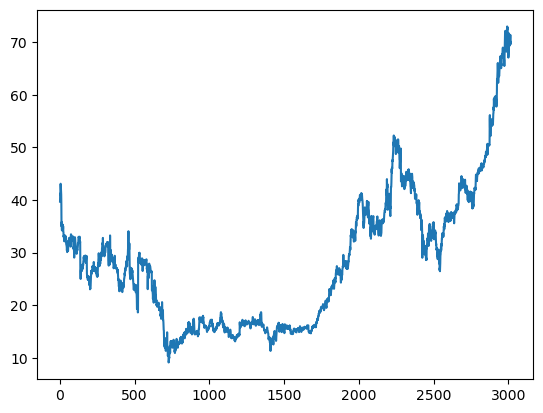

In [11]:
plt.plot(data)

In [10]:
X = data.values
X

array([[39.69],
       [41.22],
       [40.93],
       ...,
       [69.77],
       [70.12],
       [69.79]], shape=(3019, 1))

In [12]:
X_train, X_test = X[:2500], X[2500:]

In [14]:
model = Sequential([
    SimpleRNN(units=64, activation='tanh'),
    Dense(1)
])

In [16]:
model.compile(optimizer='Adam', loss='mean_absolute_error')

In [17]:
XT, yT = [], []

for i in range(len(X_train) - 90):
    d = i + 90
    XT.append(X_train[i:d,])
    yT.append(X_train[d])

In [18]:
Xt, yt = [], []

for i in range(len(X_test) - 90):
    d = i + 90
    Xt.append(X_test[i:d,])
    yt.append(X_test[d])

In [20]:
XT = np.array(XT)
Xt = np.array(Xt)

In [21]:
XT = np.reshape(XT, (XT.shape[0], XT.shape[1], 1))
Xt = np.reshape(Xt, (Xt.shape[0], Xt.shape[1], 1))

In [22]:
yT = np.array(yT)
yt = np.array(yt)

In [23]:
history = model.fit(XT, yT, epochs=100, batch_size=20,
                    validation_data=(Xt, yt))

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 16.0249 - val_loss: 36.1648
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.9167 - val_loss: 31.1833
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.8751 - val_loss: 25.4982
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.5222 - val_loss: 20.8010
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.3551 - val_loss: 17.6151
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7144 - val_loss: 14.8673
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2922 - val_loss: 12.8096
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0465 - val_loss: 11.3046
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8862 - val_loss: 10.1907
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7886 - val_loss: 9.2325
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6828 - val_loss: 8.7268
Epoch 12/100
121/121 ━━━━━━━━━━

In [24]:
XTpredict = model.predict(XT)
Xtpredict = model.predict(Xt)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [25]:
Xfinal = np.concat([XTpredict, Xtpredict], axis=0)

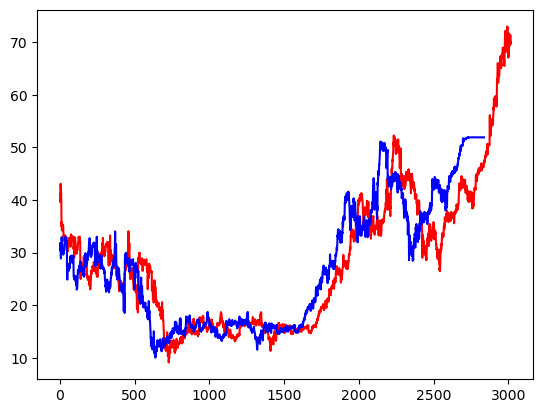

In [26]:
plt.plot(X, color='red')
plt.plot(Xfinal, color='blue')

In [30]:
model = Sequential([
    Input(shape=(90, 1)),
    GRU(units=128, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(units=64, activation='tanh'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)

])

In [31]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 90, 128)        │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,825 (397.75 KB)

 Trainable params: 101,825 (397.75 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(optimizer=Adam(), loss='mean_absolute_error')

In [33]:
model.fit(XT, yT, epochs=100, batch_size=20, validation_data=(Xt, yt))

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 13.4762 - val_loss: 26.0842
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 3.8674 - val_loss: 10.9264
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 2.7799 - val_loss: 9.2506
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 2.7362 - val_loss: 8.0430
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 2.6048 - val_loss: 7.2132
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 2.7652 - val_loss: 6.7205
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 2.5632 - val_loss: 6.5348
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 2.5932 - val_loss: 7.6696
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 2.6113 - val_loss: 6.9367
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 2.5560 - val_loss: 8.1156
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 2.7447 - val_loss: 6.7996
Epoch 12/100
121/121 ━━━━━━

In [34]:
XTpredict = model.predict(XT)
Xtpredict = model.predict(Xt)
Xfinal = np.concat([XTpredict, Xtpredict], axis=0)

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


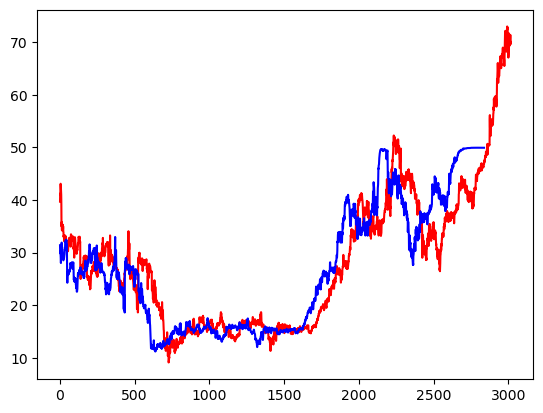

In [35]:
plt.plot(X, color='red')
plt.plot(Xfinal, color='blue')